# Loop 02 — downstream endorsement (self-supervised)

Tests the hypothesis in this loop's `README.md`: a single threshold on a
citer's **max downstream endorsement** — the citation count of the biggest
paper among its own citers — separates the anchor's 6 `landmark` rows from
its 135 `not` rows. The feature is computed from the citation graph alone;
the anchor labels only referee.

(The blind rule that governed loop 01 no longer applies here: the anchor's
labels are sealed, so citation counts may appear on screen.)

In [1]:
"""Compute max downstream endorsement for anchor rows and test separation."""

import duckdb
import matplotlib.pyplot as plt
import pandas
import seaborn

from atlas.integrations.semantic_scholar.corpus import paths
from atlas.integrations.semantic_scholar.corpus.ingest import NBUCKETS

corpus_root = paths.corpus_root()
release_id = paths.read_current_release(corpus_root)
release = paths.release_paths(release_id)
papers_glob = (release.parquet_dataset("papers") / "*.parquet").as_posix()
citations_root = release.parquet_dataset("citations").as_posix()

connection = duckdb.connect()

anchor = pandas.read_csv("../01_hand-labeled-anchor/anchor.csv")
# The 15 `unsure` rows (out-of-field) sit out: they are neither positives nor
# negatives, so they can't referee a separation claim.
labeled = anchor[anchor["label"].isin(["landmark", "not"])].copy()
print(f"corpus release: {release_id}; anchor rows under test: {len(labeled)}")
print(labeled["label"].value_counts().to_string())

corpus release: 2026-07-07; anchor rows under test: 141
label
not         135
landmark      6


## The feature: max downstream endorsement

For each anchor row, pull its own distinct citers (same dedup rule as always —
S2 ships every edge about twice, so the subquery groups by the citing paper)
and record how many there are plus the maximum citation count among them.
A `LEFT JOIN` keeps citers whose paper rows are missing, so the citer count
stays honest even where the max can't see them; rows with no citers at all
get an endorsement of 0.

In [2]:
def downstream_stats(corpusid: int) -> tuple[int, int]:
    """A paper's distinct-citer count and the max citation count among them.

    Args:
        corpusid: The paper whose downstream citers to inspect; also selects
            the edge bucket (edges are hash-partitioned on
            ``citedcorpusid % NBUCKETS``).

    Returns:
        ``(citer count, max citation count among citers)`` — ``(0, 0)`` when
        the paper has no citers in the corpus.
    """
    bucket = corpusid % NBUCKETS
    citations_glob = f"{citations_root}/bucket={bucket}/*.parquet"
    row = connection.execute(
        "SELECT count(*), coalesce(max(p.citationcount), 0) "
        f"FROM (SELECT citingcorpusid FROM read_parquet('{citations_glob}', hive_partitioning=false) "
        "      WHERE citedcorpusid = ? GROUP BY citingcorpusid) c "
        f"LEFT JOIN read_parquet('{papers_glob}') p ON p.corpusid = c.citingcorpusid",
        [corpusid],
    ).fetchone()
    return int(row[0]), int(row[1])


citer_counts: list[int] = []
max_endorsements: list[int] = []
for row_number, citer_corpusid in enumerate(labeled["citer_corpusid"], start=1):
    citer_count, max_endorsement = downstream_stats(int(citer_corpusid))
    citer_counts.append(citer_count)
    max_endorsements.append(max_endorsement)
    if row_number % 25 == 0:
        print(f"  {row_number}/{len(labeled)} rows computed")
labeled["downstream_citers"] = citer_counts
labeled["max_endorsement"] = max_endorsements
print("done")

  25/141 rows computed


  50/141 rows computed


  75/141 rows computed


  100/141 rows computed


  125/141 rows computed


done


In [3]:
landmarks = labeled[labeled["label"] == "landmark"]
nots = labeled[labeled["label"] == "not"]

lowest_landmark = int(landmarks["max_endorsement"].min())
highest_not = int(nots["max_endorsement"].max())
overlapping_nots = int((nots["max_endorsement"] >= lowest_landmark).sum())
zero_citer_nots = int((nots["downstream_citers"] == 0).sum())

print("landmarks (max_endorsement):")
print(landmarks[["seed", "citer_corpusid", "downstream_citers", "max_endorsement"]].to_string(index=False))
print(f"\nlowest landmark endorsement: {lowest_landmark:,}")
print(f"highest not endorsement:     {highest_not:,}")
print(f"nots at/above the lowest landmark: {overlapping_nots}/{len(nots)}")
print(f"nots with zero downstream citers:  {zero_citer_nots}/{len(nots)} (degenerate check)")
print("\nnot-group endorsement spread:")
print(nots["max_endorsement"].describe().to_string())

landmarks (max_endorsement):
                                          seed  citer_corpusid  downstream_citers  max_endorsement
                     Attention Is All You Need       235458009              19889             7243
                     Attention Is All You Need        52967399             115964            65373
Playing Atari with Deep Reinforcement Learning        16326763              15491            11630
Playing Atari with Deep Reinforcement Learning         6208256               9099            10251
Playing Atari with Deep Reinforcement Learning        19135734               2627             8730
                                       AlexNet       206594692             230656           183110

lowest landmark endorsement: 7,243
highest not endorsement:     6,003
nots at/above the lowest landmark: 0/135
nots with zero downstream citers:  21/135 (degenerate check)

not-group endorsement spread:
count     135.000000
mean      163.096296
std       690.060379
min        

In [4]:
# Who sits near the boundary? The highest-endorsed nots are the interesting
# negatives: papers whose biggest downstream citer is large. Naming them shows
# the mechanism (a modest paper picked up by one big citer).
boundary_nots = nots.sort_values("max_endorsement", ascending=False).head(3)
boundary_ids = [int(citer_corpusid) for citer_corpusid in boundary_nots["citer_corpusid"]]
placeholders = ", ".join("?" for _ in boundary_ids)
title_rows = connection.execute(
    f"SELECT corpusid, title, year FROM read_parquet('{papers_glob}') "
    f"WHERE corpusid IN ({placeholders})",
    boundary_ids,
).fetchall()
titles_by_id = {int(row[0]): (row[1], row[2]) for row in title_rows}
print("highest-endorsed nots (the near-boundary negatives):")
for boundary_row in boundary_nots.itertuples():
    title, year = titles_by_id.get(int(boundary_row.citer_corpusid), ("<no paper row>", ""))
    print(
        f"  endorsement={boundary_row.max_endorsement:>6,}  citers={boundary_row.downstream_citers:>5,}  "
        f"({year}) {title}"
    )

# Persist the features beside the notebook: later loops (e.g. endorsement vs.
# raw count) reuse them without re-running 141 corpus queries.
labeled.to_csv("features.csv", index=False)
print("\nfeatures written to features.csv")

highest-endorsed nots (the near-boundary negatives):
  endorsement= 6,003  citers=2,220  (2008) A Comprehensive Survey of Multiagent Reinforcement Learning
  endorsement= 4,820  citers=  337  (2022) DAMO-YOLO : A Report on Real-Time Object Detection Design
  endorsement= 1,882  citers=   97  (2002) On the Convergence of Optimistic Policy Iteration

features written to features.csv


## The picture

One strip per anchor row, split by label. The x-axis is `max_endorsement + 1`
on a **log scale** — counts are heavy-tailed, and the +1 shift lets the
zero-citer rows (endorsement 0) sit at 1 instead of vanishing off a log axis.
Two-hue categorical palette (validated colorblind-safe); the dashed line marks
the lowest landmark, i.e. the bar a separating threshold would have to clear.

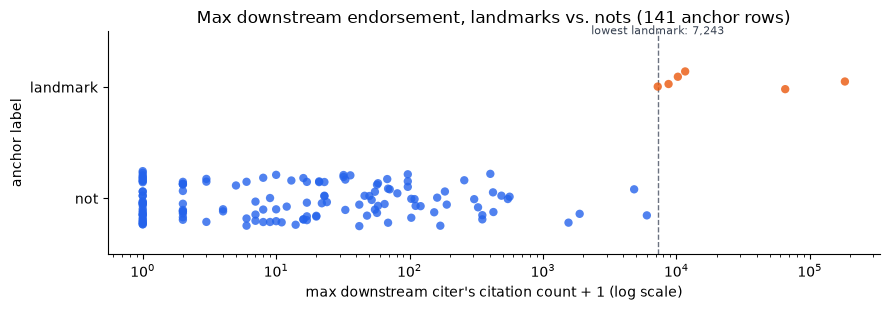

In [5]:
# Fixed hue assignment (identity, never rank): landmark = orange, not = blue.
PALETTE = {"landmark": "#EA580C", "not": "#2563EB"}

figure, axis = plt.subplots(figsize=(9, 3.2))
seaborn.stripplot(
    data=labeled.assign(shifted=labeled["max_endorsement"] + 1),
    x="shifted", y="label", hue="label", order=["landmark", "not"],
    palette=PALETTE, size=6, alpha=0.8, jitter=0.25, legend=False, ax=axis,
)
axis.set_xscale("log")
# The dashed line is the separation bar: the lowest landmark's endorsement.
axis.axvline(lowest_landmark + 1, linestyle="--", linewidth=1, color="#6B7280")
axis.text(lowest_landmark + 1, -0.45, f"lowest landmark: {lowest_landmark:,}",
          ha="center", va="bottom", fontsize=8, color="#374151")
axis.set_xlabel("max downstream citer's citation count + 1 (log scale)")
axis.set_ylabel("anchor label")
axis.set_title("Max downstream endorsement, landmarks vs. nots (141 anchor rows)")
seaborn.despine()
plt.tight_layout()
plt.show()

## Results & interpretation

**Confirmed on this anchor — but the caveats matter more than the pass.**

- **Separation exists.** Any threshold in (6,003 … 7,243] splits 6/6 landmarks
  from 135/135 nots. But the gap is *thin* — a 1.21× ratio, nearly nothing on
  a log scale — and with only six positives, the boundary's location is weakly
  determined.
- **Not a has-citers proxy.** 114/135 nots have downstream citers (median
  endorsement 13), so the feature is doing more than detecting papers with any
  citations — the degenerate outcome didn't happen.
- **The fragility mechanism is real and visible.** DAMO-YOLO: 337 citers of
  its own, yet endorsement 4,820 — one big downstream citer inflates a modest
  paper, exactly the failure mode stated up front. It didn't break separation
  here, but it compresses the gap.
- **The top boundary `not` is the loop's most interesting row:** *A
  Comprehensive Survey of Multiagent Reinforcement Learning* (2008), with
  2,220 citers of its own. Either a rater-calibration miss (a deeper-in-RL
  rater might recognize it — grist for the parked multi-rater check) or a
  genuine definitional question: is a heavily-cited *survey* a landmark, or a
  reference work? **Methodological guard: this row must NOT be relabeled
  because the feature flagged it** — that would be the circularity we've been
  quarantining (feature promotes a row, row then confirms feature). Only
  independent human judgment may relabel.
- **A free second result: raw citation count also separates this anchor.** The
  `downstream_citers` column *is* each row's own citation count, and it splits
  the groups too — lowest landmark 2,627 (Rainbow) vs. highest not 2,220 (the
  survey), an even thinner 1.18× gap. So on this anchor, **endorsement and raw
  count are indistinguishable as definitions** — both pass, neither with
  margin.

**What this buys the problem:** with six famous-tier positives, *any*
reasonable bigness feature separates — the anchor as it stands cannot
discriminate between candidate definitions. The discriminating data is
boundary cases: mid-fame landmarks and notable-but-not-landmark papers (the
survey being the first specimen). That points the workstream at richer
positives (more raters, or boundary-hunting) before more features.